### **1.Data/**

In [1]:
!pip install obspy
from obspy.clients.fdsn import Client
from obspy import UTCDateTime


In [2]:
client = Client("USGS")
catalog=client.get_events(starttime=UTCDateTime("2016-05-30"),endtime=UTCDateTime("2026-05-30"),minmagnitude=4,minlatitude=6,maxlatitude=15,minlongitude=90,maxlongitude=98)
print(catalog)
print("number of events:",len(catalog))

924 Event(s) in Catalog:
2026-05-17T09:38:20.742000Z | +11.062,  +95.127 | 4.6  mb | manual
2026-05-16T21:16:16.654000Z | +13.017,  +93.702 | 4.7  mb | manual
...
2016-07-13T17:56:32.830000Z | +12.082,  +95.170 | 4.5  mb | manual
2016-06-13T00:16:58.710000Z |  +6.384,  +94.355 | 4.2  mb | manual
To see all events call 'print(CatalogObject.__str__(print_all=True))'
number of events: 924


In [3]:
import pandas as pd
rows=[]
for event in catalog:
 origin=event.origins[0]
 mag=event.magnitudes[0]

 rows.append({"time":origin.time.datetime,"latitude":origin.latitude,"longitude":origin.longitude,"depth_km":origin.depth/1000,"magnitude":mag.mag})
df=pd.DataFrame(rows)
print(df.head(10))

                     time  latitude  longitude  depth_km  magnitude
0 2026-05-17 09:38:20.742   11.0619    95.1269    10.000        4.6
1 2026-05-16 21:16:16.654   13.0167    93.7021    96.882        4.7
2 2026-05-12 05:18:57.354    6.9852    92.3567    10.000        4.9
3 2026-05-08 03:53:33.205   10.1728    91.4911    10.000        4.6
4 2026-05-03 10:33:34.042    8.1018    91.9353    10.000        4.2
5 2026-05-01 03:12:50.564    8.0760    91.8795    10.000        4.8
6 2026-04-10 03:36:01.376    9.0424    94.0030    10.000        4.3
7 2026-04-08 22:13:51.268   10.4649    93.7220    10.000        4.6
8 2026-04-05 00:05:48.007    6.2934    92.4536    10.000        4.0
9 2026-04-01 20:14:23.446    6.1734    94.0331    41.062        4.4


In [4]:
df.to_csv("USGS andaman_nicobar_M4_catalog.csv", index=False)

print("CSV saved successfully")

CSV saved successfully


## **2.notebook/01_eda**

**(a)Magnitude Histogram**

A magnitude histogram shows the frequency distribution of earthquake magnitudes in the catalog. It helps identify the dominant magnitude range and provides insight into catalog completeness and seismic activity characteristics.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path("USGS andaman_nicobar_M4_catalog.csv"))
print(df.head())

                      time  latitude  longitude  depth_km  magnitude
0  2026-05-17 09:38:20.742   11.0619    95.1269    10.000        4.6
1  2026-05-16 21:16:16.654   13.0167    93.7021    96.882        4.7
2  2026-05-12 05:18:57.354    6.9852    92.3567    10.000        4.9
3  2026-05-08 03:53:33.205   10.1728    91.4911    10.000        4.6
4  2026-05-03 10:33:34.042    8.1018    91.9353    10.000        4.2


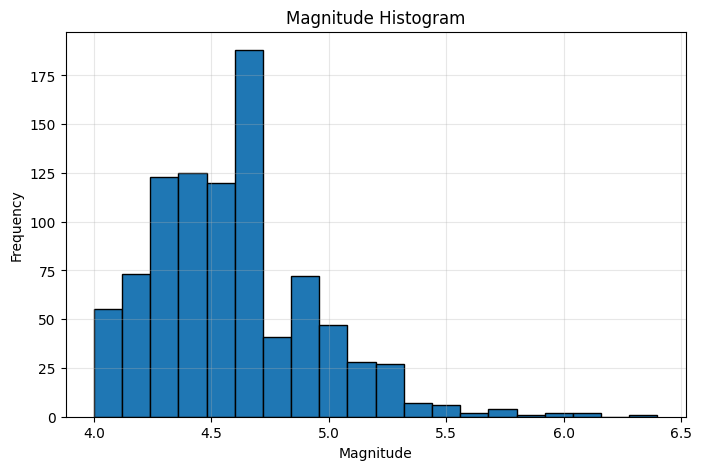

In [6]:
mags = df['magnitude']

plt.figure(figsize=(8,5))
plt.hist(mags, bins=20, edgecolor='black')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.title('Magnitude Histogram')
plt.grid(alpha=0.3)
plt.show()

**(b)Depth Distribution**

The depth distribution illustrates how earthquake hypocenters are distributed with depth. This analysis helps distinguish between shallow, intermediate, and deep seismicity and provides insight into regional tectonic processes.

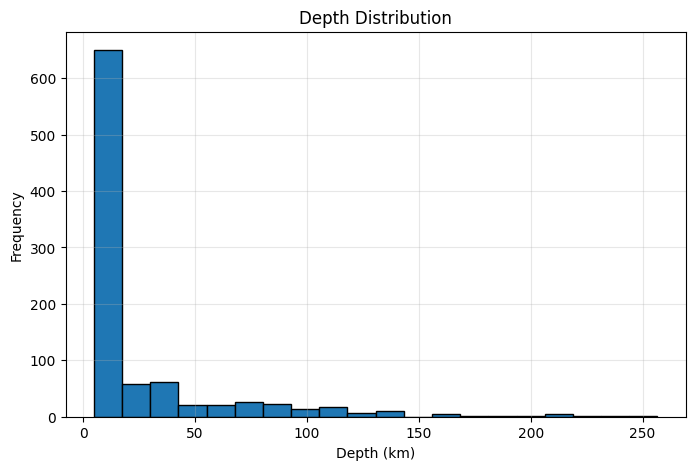

In [7]:
depths = df['depth_km']

plt.figure(figsize=(8,5))
plt.hist(depths, bins=20, edgecolor='black')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')
plt.title('Depth Distribution')
plt.grid(alpha=0.3)
plt.show()

In [8]:
print("Minimum depth:", depths.min())
print("Maximum depth:", depths.max())
print("Mean depth:", depths.mean())
print("Median depth:", depths.median())

Minimum depth: 4.79
Maximum depth: 256.65
Mean depth: 27.17039826839827
Median depth: 10.0


**(c)Cartopy Map**

In [9]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 87.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


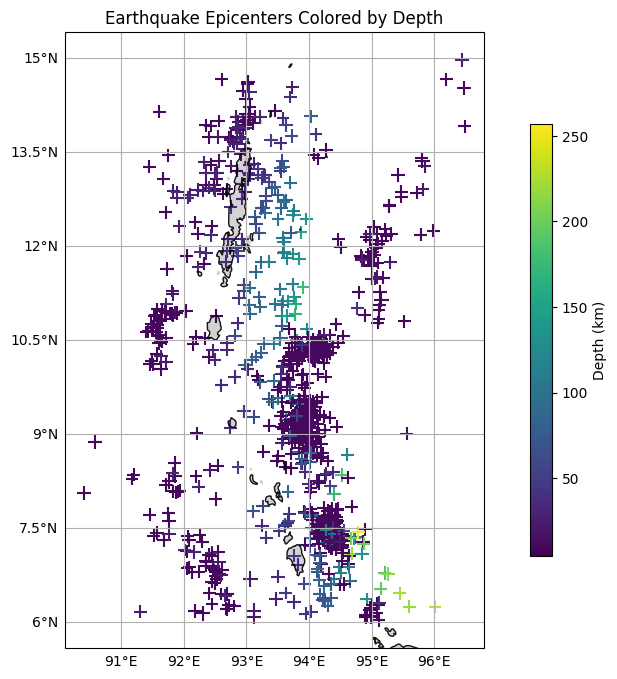

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

df=pd.read_csv(Path("USGS andaman_nicobar_M4_catalog.csv"))
fig = plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and borders
ax.coastlines(alpha=0.9)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, color='lightgrey')

# Plot epicenters colored by depth
sc = ax.scatter(df['longitude'],df['latitude'],marker='+',c=df['depth_km'],cmap='viridis',s=df['magnitude']*20,transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Depth (km)')

# Gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.title("Earthquake Epicenters Colored by Depth")
plt.show()

Spatial Distribution of Earthquakes : The epicenter map visualizes the geographic distribution of earthquakes in the study region. Plotting earthquake locations helps identify active seismic zones and spatial clustering of events.

**(d)Monthly time series**

Monthly earthquake counts are computed to examine temporal variations in seismic activity. The resulting time series forms the basis for subsequent statistical and forecasting analyses.

time
2016-06-30     1
2016-07-31     3
2016-08-31     7
2016-09-30    11
2016-10-31     2
Freq: ME, dtype: int64


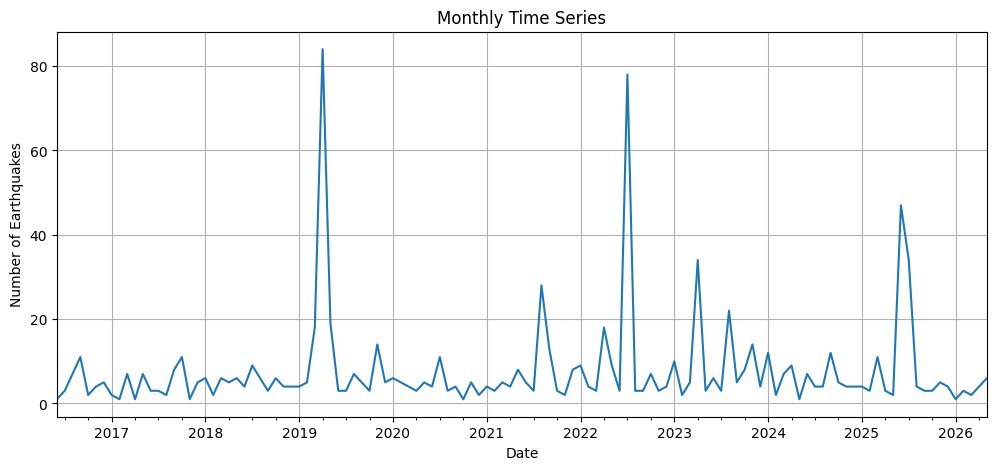

In [11]:
df['time'] = pd.to_datetime(df['time'])

# Monthly earthquake counts
monthly_counts = df.resample('ME', on='time').size()
print(monthly_counts.head())

# Plot
plt.figure(figsize=(12,5))
monthly_counts.plot()
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Monthly Time Series')
plt.grid(True)
plt.show()

**(e)inter-event time histogram**

The inter-event time distribution represents the time intervals between consecutive earthquakes in the catalog. Examining these intervals helps assess whether earthquake occurrences are random, clustered, or influenced by aftershock sequences and provides insight into the temporal characteristics of regional seismicity.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy.stats import expon
df=pd.read_csv(Path("USGS andaman_nicobar_M4_catalog.csv"))
df.head()

,time,latitude,longitude,depth_km,magnitude
0,2026-05-17 09:38:20.742,11.0619,95.1269,10.000,4.6
1,2026-05-16 21:16:16.654,13.0167,93.7021,96.882,4.7
2,2026-05-12 05:18:57.354,6.9852,92.3567,10.000,4.9
3,2026-05-08 03:53:33.205,10.1728,91.4911,10.000,4.6
4,2026-05-03 10:33:34.042,8.1018,91.9353,10.000,4.2


Estimated lambda: 0.010608054595037266
Mean inter-event time: 94.2679914626219 hours


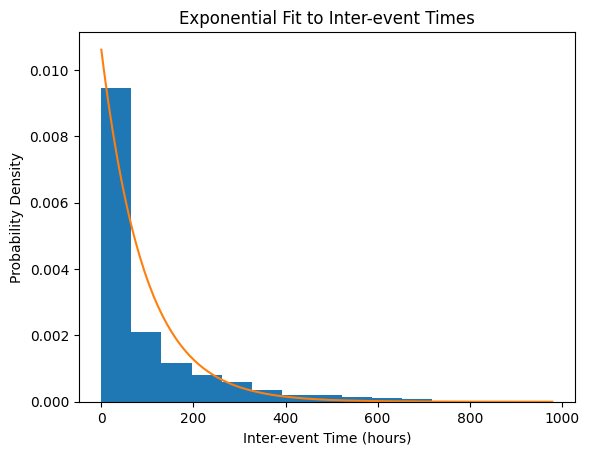

In [13]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
inter_event = df['time'].diff().dt.total_seconds()
inter_event = inter_event.dropna()
inter_event_hours = inter_event / 3600
loc, scale = expon.fit(inter_event_hours, floc=0)
lambda_est = 1 / scale

print("Estimated lambda:", lambda_est)
print("Mean inter-event time:", scale, "hours")

plt.hist(inter_event_hours, bins=15, density=True)

x = np.linspace(0, inter_event_hours.max(), 200)
pdf = expon.pdf(x, loc=loc, scale=scale)

plt.plot(x, pdf)

plt.xlabel("Inter-event Time (hours)")
plt.ylabel("Probability Density")
plt.title("Exponential Fit to Inter-event Times")

plt.show()


## **3.notebook/02_statistics**

**(a)Mc estimation(max-curvature method)**

The magnitude of completeness(Mc)represents the lowest
magnitude above which the earthquake catalog can be
considered complete. We estimate Mc using both the
Maximum Curvature and Goodness-of-Fit methods.

In [14]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path("USGS andaman_nicobar_M4_catalog.csv"))

df.head()

,time,latitude,longitude,depth_km,magnitude
0,2026-05-17 09:38:20.742,11.0619,95.1269,10.000,4.6
1,2026-05-16 21:16:16.654,13.0167,93.7021,96.882,4.7
2,2026-05-12 05:18:57.354,6.9852,92.3567,10.000,4.9
3,2026-05-08 03:53:33.205,10.1728,91.4911,10.000,4.6
4,2026-05-03 10:33:34.042,8.1018,91.9353,10.000,4.2


In [15]:
df = df.dropna(subset=["magnitude"])
mags = df["magnitude"].values
len(mags)  #so no missing values

924

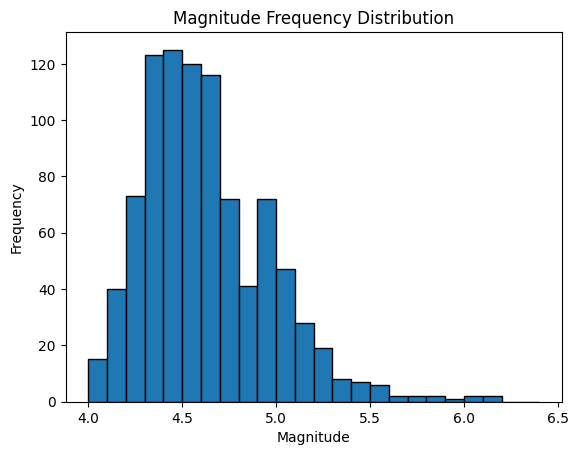

In [16]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange( mags.min(), mags.max(), 0.1)
plt.hist(mags,bins=bins,edgecolor='black')

plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Magnitude Frequency Distribution")
plt.show()

In [17]:
hist, edges = np.histogram(mags,bins=bins)
Mc = edges[np.argmax(hist)]

print("Mc =", round(Mc,2))

Mc = 4.4


**(b)Mc estimation (GFT method)**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Mc_maxc = Mc
bin_width = 0.1
candidate_Mc = np.arange(Mc_maxc-0.3,Mc_maxc+0.6,bin_width)
gft_results = []

for Mc_gft in candidate_Mc:

    complete = mags[mags >= Mc_gft]

    if len(complete) < 30:
        continue

    # Aki (1965) MLE b-value
    mean_mag = np.mean(complete)
    b = np.log10(np.exp(1)) / (mean_mag - (Mc_gft - bin_width/2))

    # Observed cumulative FMD
    bins = np.arange(Mc_gft,complete.max()+bin_width,bin_width)

    hist, edges = np.histogram(complete, bins=bins)
    obs_cum = np.cumsum(hist[::-1])[::-1]
    mag_bins = edges[:-1]

    # Synthetic GR curve
    N0 = obs_cum[0]
    syn_cum = N0 * 10**(-b*(mag_bins - Mc_gft))

    # Goodness of Fit
    R = 100 - (np.sum(np.abs(obs_cum - syn_cum))/ np.sum(obs_cum)) * 100

    gft_results.append([Mc, b, R])

gft_results = pd.DataFrame( gft_results, columns=["Mc","b","GFT"])

print(gft_results.head(6))



    Mc         b        GFT
0  4.4  0.805414  77.340110
1  4.4  0.940565  82.731586
2  4.4  1.087102  87.384901
3  4.4  1.195176  89.750541
4  4.4  1.296967  91.537788
5  4.4  1.379941  92.503198


In [20]:
mc90 = gft_results.loc[
    gft_results["GFT"] >= 90,"Mc"].min()

print("GFT Mc (90%) =", mc90)

GFT Mc (90%) = nan


**(c)fit Gutenberg-Ricter via MLE**

The Gutenberg–Richter law describes the relationship
between earthquake frequency and magnitude.
The b-value is estimated using the maximum likelihood method.

In [21]:
complete_mags = mags[mags >= Mc]

print("Number of complete events:",len(complete_mags))

Number of complete events: 673


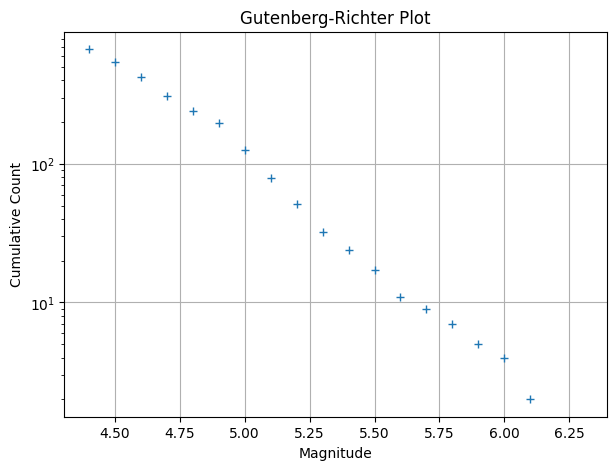

In [22]:
bins = np.arange(Mc,complete_mags.max(),0.1)
hist, edges = np.histogram(complete_mags,bins=bins)
cum_counts = np.cumsum(hist[::-1])[::-1]

plt.figure(figsize=(7,5))

plt.semilogy(edges[:-1],cum_counts,'+')
plt.xlabel("Magnitude")
plt.ylabel("Cumulative Count")
plt.title("Gutenberg-Richter Plot")
plt.grid(True)

plt.show()

**(d)b-value with bootstrap 95% CI**

Bootstrap confidence intervals were obtained by resampling
the complete magnitude catalog 1000 times with replacement.
The b-value was recomputed for each sample and the
2.5th and 97.5th percentiles were used as the 95% CI.

In [23]:
import numpy as np
dM = 0.1
mean_mag = np.mean(complete_mags)
b = 1 / (np.log(10) * (mean_mag - Mc + dM/2))
print("b-value =", round(b,3))


b-value = 1.195


In [24]:
# Bootstrap 95% Confidence Interval

boot_b = []

for i in range(1000):

    sample = np.random.choice(complete_mags,size=len(complete_mags),replace=True)
    mean_sample = np.mean(sample)

    b_sample = 1 / ( np.log(10) * (mean_sample - Mc + dM/2))
    boot_b.append(b_sample)

boot_b = np.array(boot_b)

ci_low = np.percentile(boot_b, 2.5)
ci_high = np.percentile(boot_b, 97.5)

print(f"b-value = {b:.3f}")
print(f"Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")

b-value = 1.195
Bootstrap 95% CI: [1.126, 1.281]


**(e)fit poisson null on counts**

Poisson Goodness-of-Fit : Monthly earthquake counts are compared against a
Poisson null model to evaluate departures from
random occurrence.

In [25]:
lambda_hat = monthly_counts.mean()

print("Estimated λ =", lambda_hat)

Estimated λ = 7.7


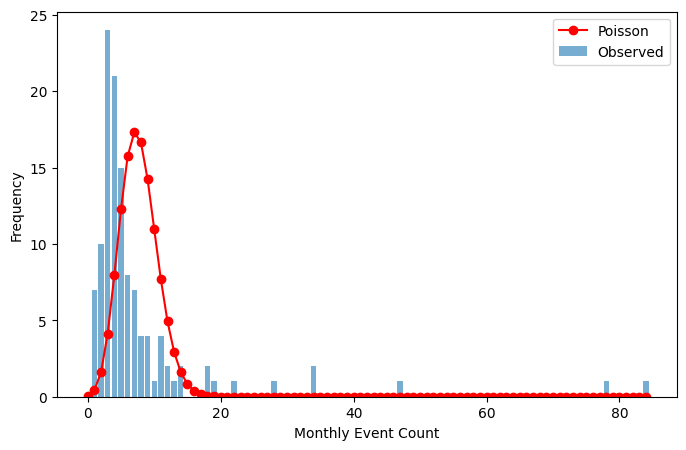

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

counts = monthly_counts.values

# observed histogram
obs_freq, bins = np.histogram(counts,bins=np.arange(counts.max()+2))
x = np.arange(0, counts.max()+1)
# expected poisson frequencies
expected = poisson.pmf(x, lambda_hat) * len(counts)

plt.figure(figsize=(8,5))
plt.bar(x, obs_freq,alpha=0.6,label='Observed')

plt.plot(x, expected, 'ro-', label='Poisson')

plt.xlabel('Monthly Event Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**(f)Plot residuals**

In [27]:
#residuals=observed count-expected count

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

df['time'] = pd.to_datetime(df['time'])
monthly_counts = df.resample('ME', on='time').size()
lam = monthly_counts.mean() # Poisson parameter

# Observed frequencies
counts = monthly_counts.values
obs_freq, bins = np.histogram(counts,bins=np.arange(counts.max()+2))
x = np.arange(len(obs_freq))

# Expected frequencies
expected = poisson.pmf(x, lam) * len(counts)

# Residuals
residuals = obs_freq - expected

print(residuals)

[-5.43392619e-02  6.58158768e+00  8.38911258e+00  1.98653890e+01
  1.30408737e+01  2.74294556e+00 -7.72988654e+00 -1.03028752e+01
 -1.26540174e+01 -1.02484371e+01 -9.97129656e+00 -3.67990759e+00
 -2.92794070e+00 -1.91885719e+00  3.94628548e-01 -8.24090679e-01
 -3.96593639e-01 -1.79633589e-01  1.92315674e+00  9.68858259e-01
 -1.19895704e-02 -4.39617581e-03  9.98461338e-01 -5.15117122e-04
 -1.65266743e-04 -5.09021570e-05 -1.50748696e-05 -4.29912947e-06
  9.99998818e-01 -3.13910574e-07 -8.05703807e-08 -2.00126429e-08
 -4.81554221e-09 -1.12362652e-09  2.00000000e+00 -5.59830387e-11
 -1.19741500e-11 -2.49191769e-12 -5.04941217e-13 -9.96935223e-14
 -1.91910030e-14 -3.60416398e-15 -6.60763397e-16 -1.18322748e-16
 -2.07064809e-17 -3.54310895e-18 -5.93085629e-19  1.00000000e+00
 -1.55869002e-20 -2.44937004e-21 -3.77202986e-22 -5.69502547e-23
 -8.43301848e-24 -1.22517438e-24 -1.74700792e-25 -2.44581108e-26
 -3.36299024e-27 -4.54298682e-28 -6.03120663e-29 -7.87123578e-30
 -1.01014192e-30 -1.27509

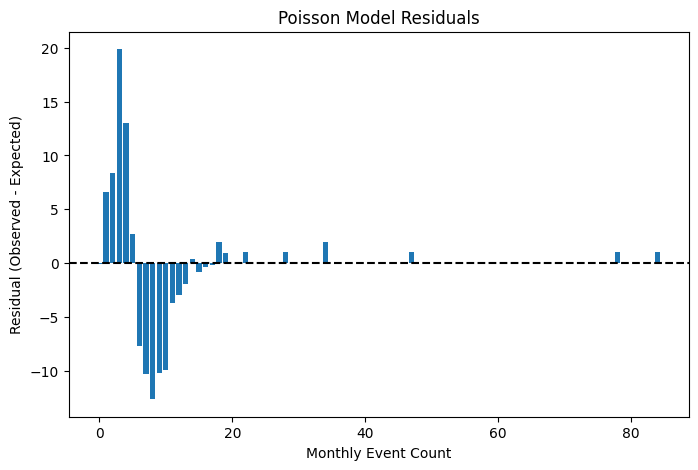

In [28]:
# Plot
plt.figure(figsize=(8,5))
plt.axhline(0, color='black', linestyle='--')

plt.bar(x, residuals)

plt.xlabel('Monthly Event Count')
plt.ylabel('Residual (Observed - Expected)')
plt.title('Poisson Model Residuals')

plt.show()